# Global Urban Air Quality Index Dataset (2015-2025) Analysis

> Add blockquote


**Introduction to Data Science - Assignment # 03**




```
# This is formatted as code
```

## Part A: Data Loading and Understanding


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import os

# Create output directories if they don't exist
os.makedirs('../outputs/charts', exist_ok=True)
os.makedirs('../outputs/results', exist_ok=True)

# Load the dataset
file_path = 'global_urban_aqi_dataset.csv' if os.path.exists('global_urban_aqi_dataset.csv') else '../dataset/global_urban_aqi_dataset.csv'
df = pd.read_csv(file_path)


In [29]:
# 2. Display first 5 rows
display(df.head())


,City,Country,Date,PM2.5,PM10,CO,NO2,O3,SO2,Temperature,Humidity,Wind Speed,AQI
0,New York,USA,2022-05-04,24.908678,44.876885,4.723030,5.931693,11.863452,4.779213,27.674347,50.610512,12.712800,64
1,Beijing,China,2024-11-05,52.071351,84.019623,4.886720,10.150164,24.950850,5.787169,23.142473,41.839518,2.938481,136
2,Sao Paulo,Brazil,2023-05-19,48.071118,74.475282,4.725252,11.211235,25.043690,4.999006,23.756980,47.987226,8.541531,123
3,Cairo,Egypt,2024-03-29,49.661391,60.465028,3.992289,11.745090,15.316625,5.258864,0.403299,33.436279,10.984306,101
4,Beijing,China,2021-06-24,69.656841,102.043517,8.298896,14.242956,31.520623,8.139361,30.571222,66.872366,1.184799,172


In [50]:
# 3. Show number of rows and columns
print("Rows and Columns:", df.shape)


Rows and Columns: (500, 19)


In [53]:
# 4. Display all column names
print("Column Names:")
print(df.columns.tolist())


Column Names:
['City', 'Country', 'Date', 'PM2.5', 'PM10', 'CO', 'NO2', 'O3', 'SO2', 'Temperature', 'Humidity', 'Wind Speed', 'AQI', 'Year', 'Month', 'AQI Category', 'Cluster', 'PC1', 'PC2']


In [52]:
# 5. Display data types
print("Data Types:")
print(df.dtypes)


Data Types:
City                    object
Country                 object
Date            datetime64[ns]
PM2.5                  float64
PM10                   float64
CO                     float64
NO2                    float64
O3                     float64
SO2                    float64
Temperature            float64
Humidity               float64
Wind Speed             float64
AQI                      int64
Year                     int32
Month                    int32
AQI Category            object
Cluster                  int32
PC1                    float64
PC2                    float64
dtype: object


In [33]:
# 6. Check missing values
print("Missing Values:")
print(df.isnull().sum())


Missing Values:
City           0
Country        0
Date           0
PM2.5          6
PM10           0
CO             0
NO2            0
O3             0
SO2            0
Temperature    6
Humidity       0
Wind Speed     0
AQI            0
dtype: int64


In [34]:
# 7. Check duplicate records
print("Duplicate Records:", df.duplicated().sum())


Duplicate Records: 5


### Short Explanation of Important Columns
- **City/Country**: The location of the air quality reading.
- **Date**: When the reading was taken.
- **PM2.5, PM10, CO, NO2, O3, SO2**: Various pollutants that contribute to air pollution.
- **AQI**: The overall Air Quality Index, which is our target variable for prediction.


## Part B: Data Cleaning


In [55]:
# 9. Remove duplicate rows
df.drop_duplicates(inplace=True)
print("Duplicates after removal:", df.duplicated().sum())


Duplicates after removal: 0


In [54]:
# 10. Handle missing values (Fill numerical with median)
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())
print("Missing values after filling:")
print(df.isnull().sum())


Missing values after filling:
City            0
Country         0
Date            0
PM2.5           0
PM10            0
CO              0
NO2             0
O3              0
SO2             0
Temperature     0
Humidity        0
Wind Speed      0
AQI             0
Year            0
Month           0
AQI Category    0
Cluster         0
PC1             0
PC2             0
dtype: int64


In [56]:
# 11 & 12. Convert date and create year/month columns
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
display(df[['Date', 'Year', 'Month']].head())


,Date,Year,Month
0,2022-05-04,2022,5
1,2024-11-05,2024,11
2,2023-05-19,2023,5
3,2024-03-29,2024,3
4,2021-06-24,2021,6


In [38]:
# 13 & 14. Ensure numerical format (done above implicitly, but let's double check)
df.dropna(inplace=True) # Drop any remaining NaNs in categorical fields
print(df.shape)


(500, 15)


## Part C: AQI Category Creation


In [39]:
# Create AQI categories based on standard ranges
def get_aqi_category(aqi):
    if aqi <= 50: return 'Good'
    elif aqi <= 100: return 'Moderate'
    elif aqi <= 150: return 'Unhealthy for Sensitive Groups'
    elif aqi <= 200: return 'Unhealthy'
    elif aqi <= 300: return 'Very Unhealthy'
    else: return 'Hazardous'

if 'AQI Category' not in df.columns and 'AQI' in df.columns:
    df['AQI Category'] = df['AQI'].apply(get_aqi_category)

display(df[['AQI', 'AQI Category']].head())


,AQI,AQI Category
0,64,Moderate
1,136,Unhealthy for Sensitive Groups
2,123,Unhealthy for Sensitive Groups
3,101,Unhealthy for Sensitive Groups
4,172,Unhealthy




```
`# This is formatted as code`
```

## Part D: Exploratory Data Analysis


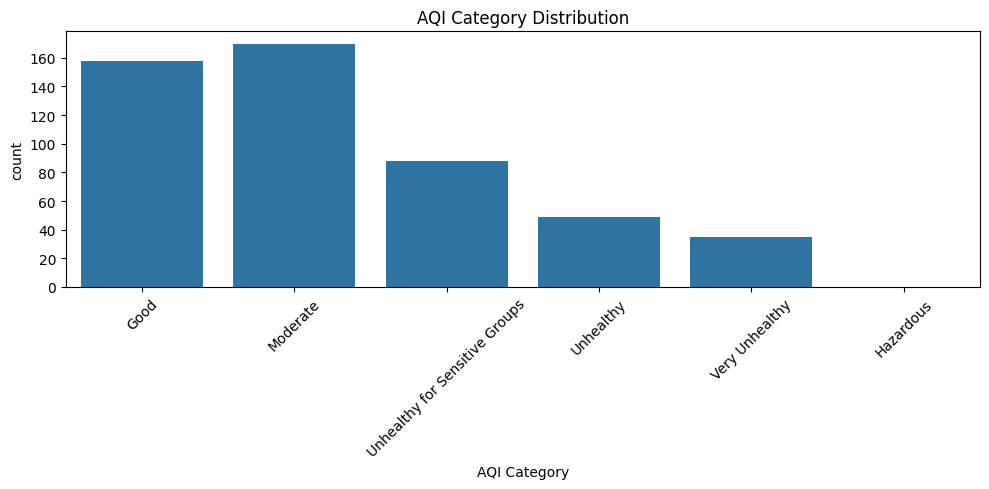

In [40]:
# 1. AQI category distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='AQI Category', order=['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous'])
plt.title('AQI Category Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/charts/aqi_distribution.png')
plt.show()


**Explanation:** This chart shows how many records fall into each AQI class. It helps us understand the general air quality distribution in our dataset.


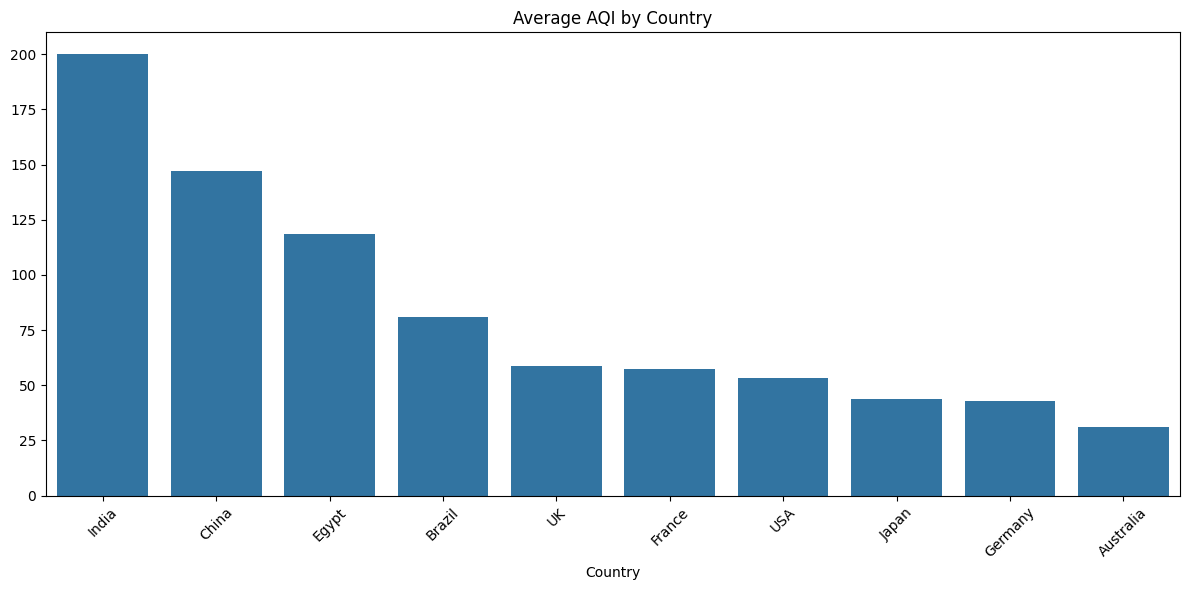

In [41]:
# 2. Average AQI by Country
plt.figure(figsize=(12, 6))
avg_aqi_country = df.groupby('Country')['AQI'].mean().sort_values(ascending=False)
sns.barplot(x=avg_aqi_country.index, y=avg_aqi_country.values)
plt.title('Average AQI by Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/charts/avg_aqi_country.png')
plt.show()


**Explanation:** Comparing average AQI across countries reveals which regions suffer the most from air pollution on average.


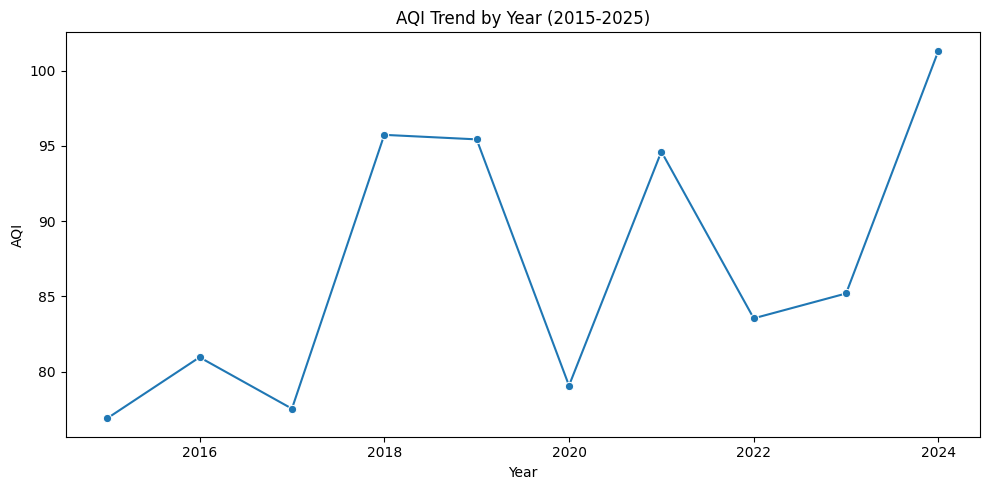

In [42]:
# 3. AQI trend by year
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Year', y='AQI', errorbar=None, marker='o')
plt.title('AQI Trend by Year (2015-2025)')
plt.tight_layout()
plt.savefig('../outputs/charts/aqi_trend_year.png')
plt.show()


**Explanation:** The line chart illustrates the overall global trend of air quality over the 10-year period, indicating if pollution is worsening or improving.


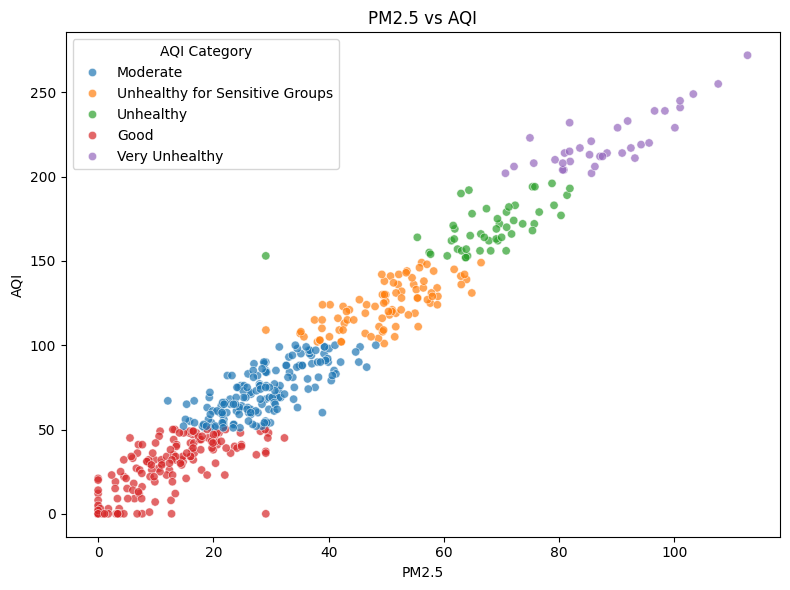

In [43]:
# 4. PM2.5 vs AQI scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PM2.5', y='AQI', hue='AQI Category', alpha=0.7)
plt.title('PM2.5 vs AQI')
plt.tight_layout()
plt.savefig('../outputs/charts/pm25_vs_aqi.png')
plt.show()


**Explanation:** This scatter plot highlights the strong relationship between PM2.5 concentrations and the overall AQI value.


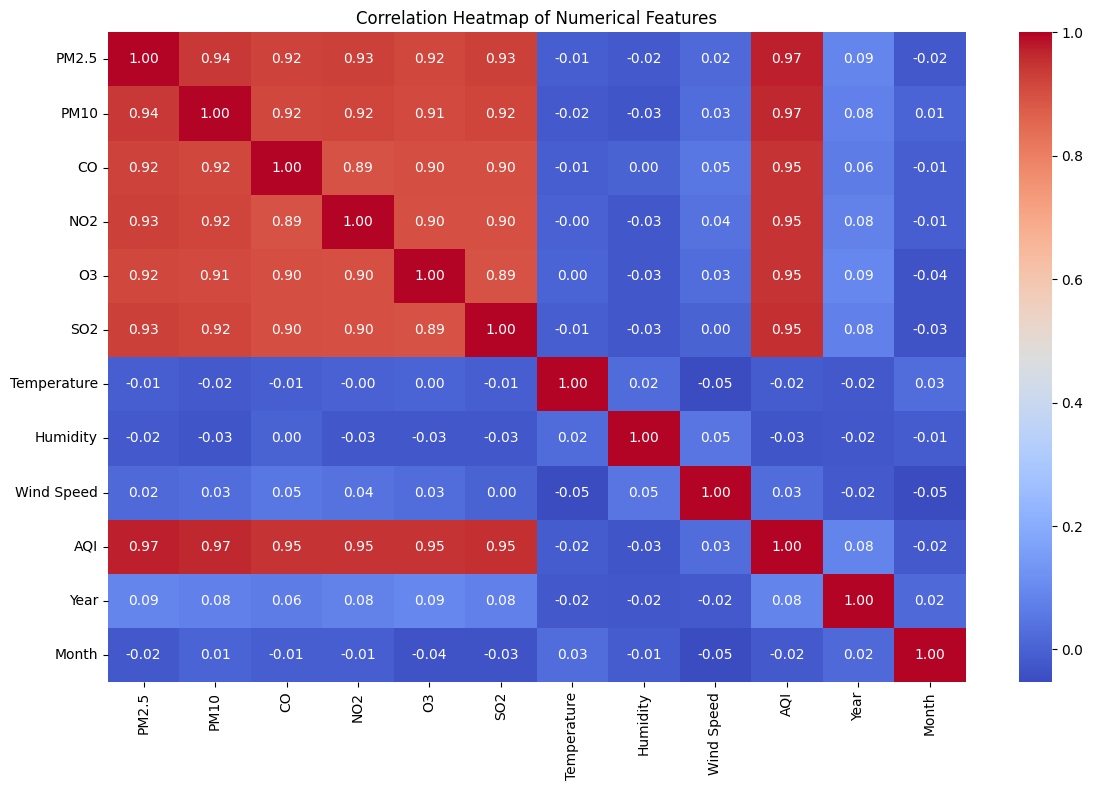

In [44]:
# 5. Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('../outputs/charts/correlation_heatmap.png')
plt.show()


**Explanation:** The heatmap shows linear relationships between all numerical variables. We can clearly see which pollutants are most correlated with AQI.


 Basic Statistics Requirement

---




In [45]:
print("Mean AQI:", df['AQI'].mean())
print("Minimum AQI:", df['AQI'].min())
print("Maximum AQI:", df['AQI'].max())
print("Standard deviation of AQI:", df['AQI'].std())

highest_aqi_loc = df.loc[df['AQI'].idxmax()]
lowest_aqi_loc = df.loc[df['AQI'].idxmin()]

print(f"Highest AQI Location: {highest_aqi_loc['City']}, {highest_aqi_loc['Country']} (AQI: {highest_aqi_loc['AQI']})")
print(f"Lowest AQI Location: {lowest_aqi_loc['City']}, {lowest_aqi_loc['Country']} (AQI: {lowest_aqi_loc['AQI']})")


Mean AQI: 87.13
Minimum AQI: 0
Maximum AQI: 272
Standard deviation of AQI: 59.95359845693894
Highest AQI Location: Delhi, India (AQI: 272)
Lowest AQI Location: Berlin, Germany (AQI: 0)


## Supervised Learning Task
### Part E: KNN Classification


In [46]:
# Select numerical features and target
features = ['PM2.5', 'PM10', 'CO', 'NO2', 'O3', 'SO2', 'Temperature', 'Humidity', 'Wind Speed']
X = df[features]
y = df['AQI Category']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Test multiple values of k
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"KNN Accuracy (k={k}): {acc:.4f}")

# Detailed report for best K (let's say k=5)
knn_best = KNeighborsClassifier(n_neighbors=5)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn = knn_best.predict(X_test_scaled)

print("\nConfusion Matrix (KNN k=5):\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report (KNN k=5):\n", classification_report(y_test, y_pred_knn, zero_division=0))


KNN Accuracy (k=3): 0.8200
KNN Accuracy (k=5): 0.8400
KNN Accuracy (k=7): 0.8300

Confusion Matrix (KNN k=5):
 [[27  4  0  0  0]
 [ 7 29  0  2  0]
 [ 0  0  6  1  0]
 [ 0  2  0 16  0]
 [ 0  0  0  0  6]]

Classification Report (KNN k=5):
                                 precision    recall  f1-score   support

                          Good       0.79      0.87      0.83        31
                      Moderate       0.83      0.76      0.79        38
                     Unhealthy       1.00      0.86      0.92         7
Unhealthy for Sensitive Groups       0.84      0.89      0.86        18
                Very Unhealthy       1.00      1.00      1.00         6

                      accuracy                           0.84       100
                     macro avg       0.89      0.88      0.88       100
                  weighted avg       0.84      0.84      0.84       100



### Part F: Naive Bayes Classification


In [47]:
# Train Gaussian Naive Bayes
nb = GaussianNB()
# Naive bayes can work with unscaled data, but scaled is fine too. Let's use unscaled for traditional approach
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print("\nConfusion Matrix (Naive Bayes):\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report (Naive Bayes):\n", classification_report(y_test, y_pred_nb, zero_division=0))


Naive Bayes Accuracy: 0.8700

Confusion Matrix (Naive Bayes):
 [[28  3  0  0  0]
 [ 6 29  0  3  0]
 [ 0  0  7  0  0]
 [ 0  0  0 18  0]
 [ 0  0  1  0  5]]

Classification Report (Naive Bayes):
                                 precision    recall  f1-score   support

                          Good       0.82      0.90      0.86        31
                      Moderate       0.91      0.76      0.83        38
                     Unhealthy       0.88      1.00      0.93         7
Unhealthy for Sensitive Groups       0.86      1.00      0.92        18
                Very Unhealthy       1.00      0.83      0.91         6

                      accuracy                           0.87       100
                     macro avg       0.89      0.90      0.89       100
                  weighted avg       0.88      0.87      0.87       100



## Unsupervised Learning Task
### Part G: K-Means Clustering


In [48]:
# Remove AQI Category (already done, X contains only numerical features)
# Standardize the data (using all X now)
X_scaled_full = scaler.fit_transform(X)

# Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled_full)

# Table showing average values per cluster
cluster_summary = df.groupby('Cluster')[features + ['AQI']].mean()
display(cluster_summary)


,PM2.5,PM10,CO,NO2,O3,SO2,Temperature,Humidity,Wind Speed,AQI
Cluster,,,,,,,,,,
0,38.927987,59.241886,4.737863,9.773067,19.415064,4.864929,20.015726,59.686679,9.918411,97.574586
1,74.317695,111.944656,9.321524,18.339934,37.499571,9.260761,19.905794,61.653958,10.980320,184.739583
2,15.270236,21.782546,1.901123,3.834805,7.514375,1.792100,20.214247,61.593844,10.543301,36.632287


### Part H: PCA Visualization


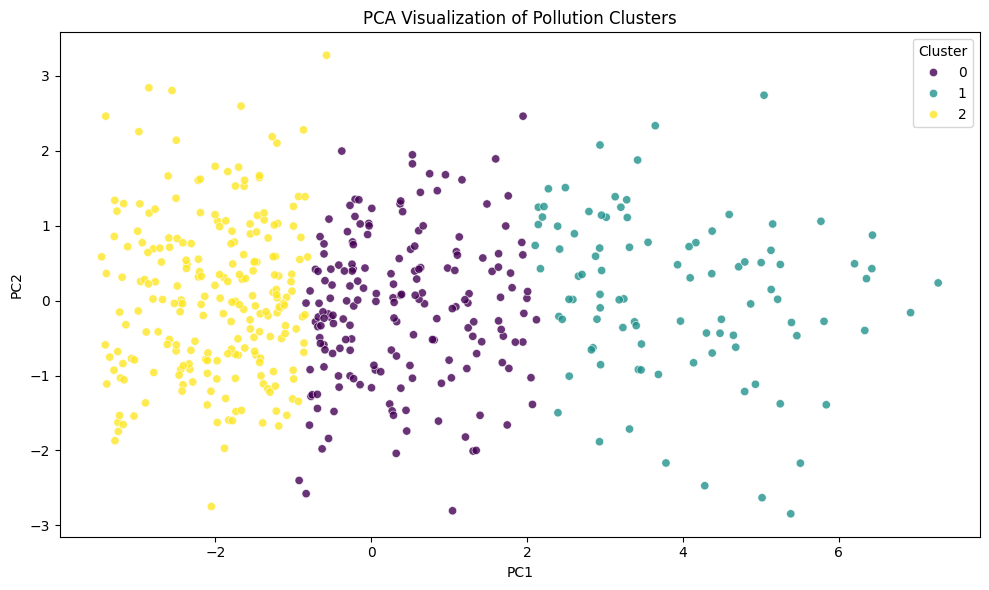

Explained Variance by PC1: 61.83%
Explained Variance by PC2: 11.77%
Total Explained Variance: 73.60%


In [49]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_full)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# Plot PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', palette='viridis', alpha=0.8)
plt.title('PCA Visualization of Pollution Clusters')
plt.tight_layout()
plt.savefig('../outputs/charts/pca_clusters.png')
plt.show()

# Explained variance
print(f"Explained Variance by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Explained Variance by PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total Explained Variance: {sum(pca.explained_variance_ratio_)*100:.2f}%")
